# GECCO 2019 Water Quality

## 1. Imports & Configuration

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, os, json, time
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    f1_score, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, balanced_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Boosting ──────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── Hyperparameter Optimization ───────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Explainability ────────────────────────────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — skipping explainability section')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
PALETTE = sns.color_palette('husl', 12)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' All libraries loaded successfully')

 All libraries loaded successfully


## 2. Load & Explore Data

In [ ]:
data_path = 'dataset/d3.csv'
df_raw = pd.read_csv(data_path)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (218880, 9)


,Unnamed: 0,Time,Tp,pH,Cond,Turb,SAC,PFM,Event
0,1,2017-07-01 00:00:00,6.94,8.60774,0.020954,0.125931,3.58683,43.7559,False
1,2,2017-07-01 00:01:00,6.93,8.60589,0.020965,0.127219,3.59025,43.4366,False
2,3,2017-07-01 00:02:00,6.94,8.60220,0.020968,0.126482,3.58318,43.5994,False


In [3]:
# Drop irrelevant columns — keep Time for feature engineering if present
drop_cols = [c for c in ['Unnamed: 0'] if c in df_raw.columns]
df = df_raw.drop(columns=drop_cols).copy()

# Preserve time index for rolling features
time_col = 'Time' if 'Time' in df.columns else None
if time_col:
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.sort_values(time_col).reset_index(drop=True)

print('Class distribution:')
print(df['Event'].value_counts())
print(f"\nImbalance ratio: {df['Event'].value_counts().max() / df['Event'].value_counts().min():.1f}x")

Class distribution:
Event
False    218252
True        628
Name: count, dtype: int64

Imbalance ratio: 347.5x


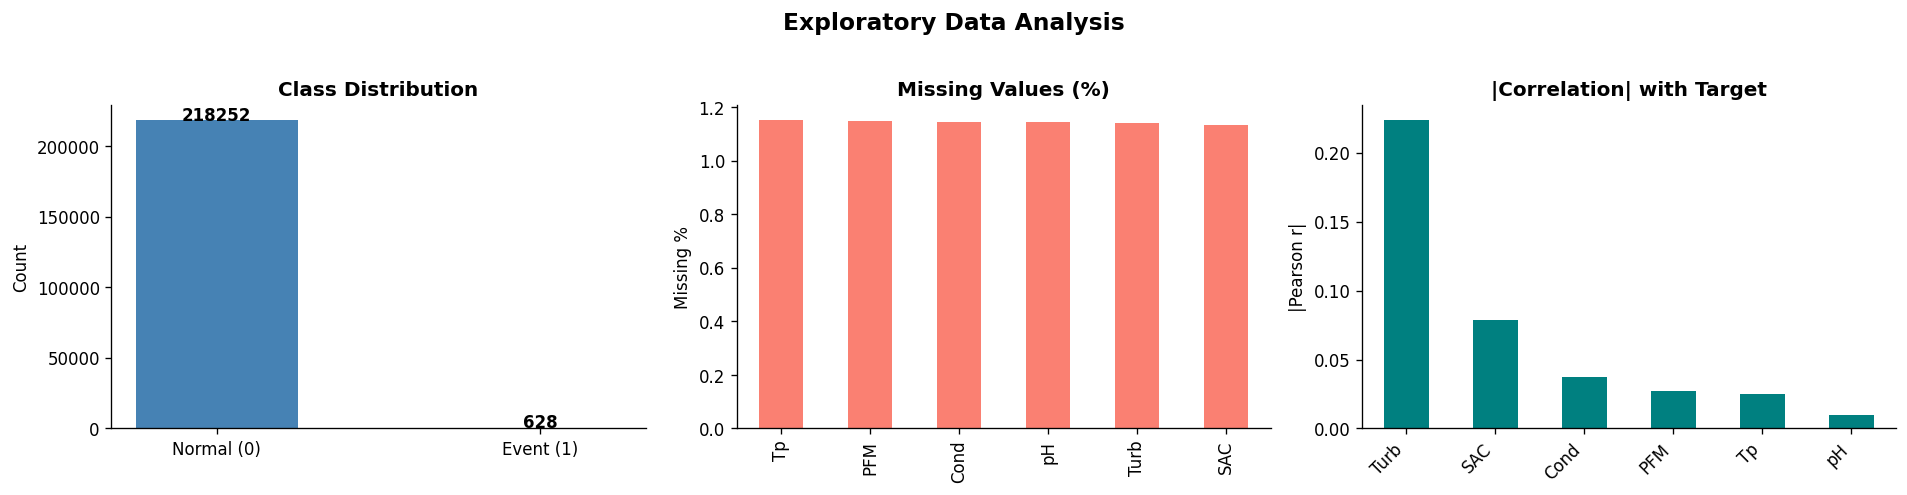

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df['Event'].value_counts()
axes[0].bar(['Normal (0)', 'Event (1)'], counts.values, color=['steelblue', 'coral'], width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Missing values
feat_cols = [c for c in df.columns if c not in ['Event', 'Time']]
miss = df[feat_cols].isnull().mean() * 100
miss[miss > 0].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Missing Values (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Missing %')
if miss.sum() == 0:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[1].transAxes)

# Correlation with target
corr = df[feat_cols + ['Event']].corr()['Event'].drop('Event').abs().sort_values(ascending=False)
corr.plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('|Correlation| with Target', fontsize=12, fontweight='bold')
axes[2].set_ylabel('|Pearson r|')
plt.xticks(rotation=45, ha='right')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

We engineer domain-aware features on top of the raw sensor readings:
- **Rolling statistics** (mean, std, min, max over windows of 5 and 15 samples)
- **Rate of change** (first-order differences per sensor)
- **Interaction terms** (Turb × SAC, Cond × pH)
- **Anomaly indicators** (z-score flags > 3σ)

In [5]:
def engineer_features(df: pd.DataFrame, sensor_cols: list) -> pd.DataFrame:
    """Add rolling, diff, interaction, and anomaly features."""
    df = df.copy()

    # --- Rolling statistics (windows: 5, 15) ---
    for w in [5, 15]:
        for col in sensor_cols:
            rolled = df[col].rolling(w, min_periods=1)
            df[f'{col}_roll{w}_mean'] = rolled.mean()
            df[f'{col}_roll{w}_std']  = rolled.std().fillna(0)
            df[f'{col}_roll{w}_max']  = rolled.max()
            df[f'{col}_roll{w}_min']  = rolled.min()

    # --- Rate of change (first-order diff) ---
    for col in sensor_cols:
        df[f'{col}_diff1'] = df[col].diff(1).fillna(0)
        df[f'{col}_diff2'] = df[col].diff(2).fillna(0)

    # --- Key interaction terms (domain knowledge) ---
    if 'Turb' in sensor_cols and 'SAC' in sensor_cols:
        df['Turb_x_SAC'] = df['Turb'] * df['SAC']
    if 'Cond' in sensor_cols and 'pH' in sensor_cols:
        df['Cond_x_pH'] = df['Cond'] * df['pH']
    if 'Turb' in sensor_cols and 'PFM' in sensor_cols:
        df['Turb_x_PFM'] = df['Turb'] * df['PFM']

    # --- Z-score anomaly flags (per column) ---
    for col in sensor_cols:
        mu, sigma = df[col].mean(), df[col].std()
        if sigma > 0:
            df[f'{col}_zscore_flag'] = ((df[col] - mu).abs() / sigma > 3).astype(int)

    # --- Aggregate anomaly count ---
    flag_cols = [c for c in df.columns if c.endswith('_zscore_flag')]
    df['total_anomaly_flags'] = df[flag_cols].sum(axis=1)

    return df

# Identify sensor columns (everything except Event and Time)
sensor_cols = [c for c in df.columns if c not in ['Event', 'Time']]

df_feat = engineer_features(df, sensor_cols)
# Drop Time before modelling
if 'Time' in df_feat.columns:
    df_feat = df_feat.drop(columns=['Time'])

print(f'Features before engineering : {len(sensor_cols)}')
print(f'Features after  engineering : {df_feat.shape[1] - 1}')  # minus Event
print(f'Dataset shape               : {df_feat.shape}')

Features before engineering : 6
Features after  engineering : 76
Dataset shape               : (218880, 77)


## 4. Pre-processing & Data Split

In [7]:
X = df_feat.drop('Event', axis=1)
y = df_feat['Event'].astype(int)

# --- Impute missing values (fit on full X; no leakage risk on features only) ---
imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# --- Stratified 80/20 split ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# 5-fold stratified CV on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Train size : {X_train_full.shape[0]:,}  |  Positive rate: {y_train_full.mean()*100:.2f}%')
print(f'Test  size : {X_test.shape[0]:,}  |  Positive rate: {y_test.mean()*100:.2f}%')
print(f'Features   : {X_train_full.shape[1]}')

Train size : 175,104  |  Positive rate: 0.29%
Test  size : 43,776  |  Positive rate: 0.29%
Features   : 76


## 5. Helper Utilities

In [8]:
CV_METRICS = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
    'average_precision': 'average_precision',  # PR-AUC (better for imbalanced)
}

def run_cv(name, pipe, X, y, cv, imbalanced=False):
    """Run cross-validation and return a result dict."""
    t0 = time.time()
    scores = cross_validate(pipe, X, y, cv=cv, scoring=CV_METRICS, n_jobs=-1)
    elapsed = time.time() - t0
    return {
        'Model': name,
        'Accuracy':   scores['test_accuracy'].mean(),
        'Precision':  scores['test_precision'].mean(),
        'Recall':     scores['test_recall'].mean(),
        'F1-Score':   scores['test_f1'].mean(),
        'AUC-ROC':    scores['test_roc_auc'].mean(),
        'PR-AUC':     scores['test_average_precision'].mean(),
        'F1 Std':     scores['test_f1'].std(),
        'Time (s)':   round(elapsed, 1),
    }

def plot_leaderboard(df_results, title, top_n=10):
    df_top = df_results.head(top_n).copy()
    metrics = ['F1-Score', 'AUC-ROC', 'PR-AUC', 'Recall', 'Precision']
    fig, axes = plt.subplots(1, len(metrics), figsize=(22, 5), sharey=True)
    for ax, metric in zip(axes, metrics):
        bars = ax.barh(df_top['Model'][::-1], df_top[metric][::-1], color=PALETTE[:top_n])
        ax.set_xlabel(metric, fontsize=10)
        ax.set_xlim(df_top[metric].min() * 0.97, 1.0)
        for bar in bars:
            w = bar.get_width()
            ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{w:.4f}', va='center', fontsize=8)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_roc_pr(trained_pipes, X_test, y_test, top_names, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for i, name in enumerate(top_names):
        pipe = trained_pipes[name]
        y_proba = pipe.predict_proba(X_test)[:, 1]
        # ROC
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        ax1.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.4f})', color=PALETTE[i])
        # PR
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        ax2.plot(rec, prec, label=f'{name} (AP={ap:.4f})', color=PALETTE[i])
    # ROC
    ax1.plot([0,1],[0,1],'k--', lw=0.8)
    ax1.set_xlim([0, 0.15]); ax1.set_ylim([0.85, 1.01])
    ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
    ax1.set_title(f'ROC (Zoomed) — {title}', fontweight='bold')
    ax1.legend(fontsize=7, loc='lower right')
    # PR
    baseline = y_test.mean()
    ax2.axhline(baseline, color='k', ls='--', lw=0.8, label=f'Baseline ({baseline:.3f})')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall — {title}', fontweight='bold')
    ax2.legend(fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.show()

def evaluate_on_test(pipe, X_test, y_test, name):
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    print(f'\n── Test-set evaluation: {name} ──────────────────────────────')
    print(classification_report(y_test, y_pred, digits=4))
    print(f'MCC  : {matthews_corrcoef(y_test, y_pred):.4f}')
    print(f'Bal. Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
    print(f'PR-AUC: {average_precision_score(y_test, y_proba):.4f}')
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Event'], yticklabels=['Normal','Event'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    return y_proba

print(' Utilities defined')

 Utilities defined


---
# PHASE 1: Training WITHOUT Data Imbalance Mitigation

Models are trained as-is on the imbalanced dataset. This establishes the **baseline** and shows how imbalance affects performance.

### 5.1 Define Base Classifiers (Phase 1)

In [9]:
# Compute scale_pos_weight for XGBoost (ratio neg/pos) — NOT used in Phase 1
neg, pos = (y_train_full == 0).sum(), (y_train_full == 1).sum()
spw = neg / pos

phase1_classifiers = {
    'Logistic Regression':   LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'),
    'Decision Tree':         DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Extra Trees':           ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    'Random Forest':         RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                                     n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                         max_depth=5, subsample=0.8,
                                                         random_state=RANDOM_STATE),
    'AdaBoost':              AdaBoostClassifier(n_estimators=200, learning_rate=0.1,
                                                 random_state=RANDOM_STATE),
    'XGBoost':               XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                            subsample=0.8, colsample_bytree=0.8,
                                            min_child_weight=3, gamma=0.1,
                                            eval_metric='logloss', n_jobs=-1,
                                            random_state=RANDOM_STATE),
    'LightGBM':              LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                             min_child_samples=10, colsample_bytree=0.8,
                                             subsample=0.8, n_jobs=-1,
                                             random_state=RANDOM_STATE, verbose=-1),
    'CatBoost':              CatBoostClassifier(iterations=500, learning_rate=0.05, depth=7,
                                                 l2_leaf_reg=3, loss_function='Logloss',
                                                 thread_count=-1, verbose=0,
                                                 random_seed=RANDOM_STATE),
    'SVM (RBF)':             SVC(C=10, kernel='rbf', gamma='scale',
                                  probability=True, random_state=RANDOM_STATE),
    'MLP':                   MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                                            learning_rate_init=1e-3, max_iter=1000,
                                            early_stopping=True, validation_fraction=0.1,
                                            random_state=RANDOM_STATE),
}
print(f'Phase 1 — {len(phase1_classifiers)} classifiers ready')

Phase 1 — 12 classifiers ready


### 5.2 Cross-Validation (Phase 1)

In [10]:
phase1_results = []
phase1_pipes   = {}

for name, clf in phase1_classifiers.items():
    print(f'    {name} ...', end=' ', flush=True)
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('clf',    clf)
    ])
    result = run_cv(name, pipe, X_train_full, y_train_full, cv)
    phase1_results.append(result)
    # Refit on full train
    pipe.fit(X_train_full, y_train_full)
    phase1_pipes[name] = pipe
    print(f"F1={result['F1-Score']:.4f}  AUC={result['AUC-ROC']:.4f}")

p1_df = (pd.DataFrame(phase1_results)
           .sort_values('F1-Score', ascending=False)
           .reset_index(drop=True))
print('\n Phase 1 CV complete')

    Logistic Regression ... F1=0.7474  AUC=0.9663
    K-Nearest Neighbors ... F1=0.8589  AUC=0.9680
    Decision Tree ... F1=0.8723  AUC=0.9115
    Extra Trees ... F1=0.9514  AUC=0.9976
    Random Forest ... F1=0.9291  AUC=0.9955
    Gradient Boosting ... F1=0.8461  AUC=0.9753
    AdaBoost ... F1=0.4677  AUC=0.9891
    XGBoost ... F1=0.9276  AUC=0.9970
    LightGBM ... F1=0.9138  AUC=0.9954
    CatBoost ... F1=0.9368  AUC=0.9971
    SVM (RBF) ... F1=0.6687  AUC=0.9724
    MLP ... F1=0.8469  AUC=0.9895

 Phase 1 CV complete


In [11]:
# Display leaderboard
display_cols = ['Model','F1-Score','AUC-ROC','PR-AUC','Precision','Recall','Accuracy','F1 Std','Time (s)']
p1_df[display_cols].style.background_gradient(subset=['F1-Score','AUC-ROC','PR-AUC'], cmap='YlGn')

,Model,F1-Score,AUC-ROC,PR-AUC,Precision,Recall,Accuracy,F1 Std,Time (s)
0,Extra Trees,0.951430,0.997580,0.962662,0.987184,0.918337,0.999732,0.013947,44.000000
1,CatBoost,0.936776,0.997081,0.950362,0.991031,0.888396,0.999657,0.018328,49.200000
2,Random Forest,0.929076,0.995454,0.955147,0.988627,0.876495,0.999617,0.021180,135.400000
3,XGBoost,0.927618,0.997035,0.949378,0.977792,0.882455,0.999606,0.020814,18.500000
4,LightGBM,0.913762,0.995407,0.919818,0.954828,0.876535,0.999526,0.028579,22.000000
5,Decision Tree,0.872252,0.911470,0.793221,0.961438,0.798792,0.999332,0.024547,7.000000
6,K-Nearest Neighbors,0.858925,0.968007,0.910672,0.967874,0.773050,0.999275,0.028402,438.600000
7,MLP,0.846915,0.989498,0.869725,0.929298,0.784673,0.999189,0.024485,42.800000
8,Gradient Boosting,0.846125,0.975303,0.725067,0.880758,0.814733,0.999149,0.031268,836.100000
9,Logistic Regression,0.747415,0.966263,0.750328,0.920111,0.633545,0.998784,0.038150,90.300000


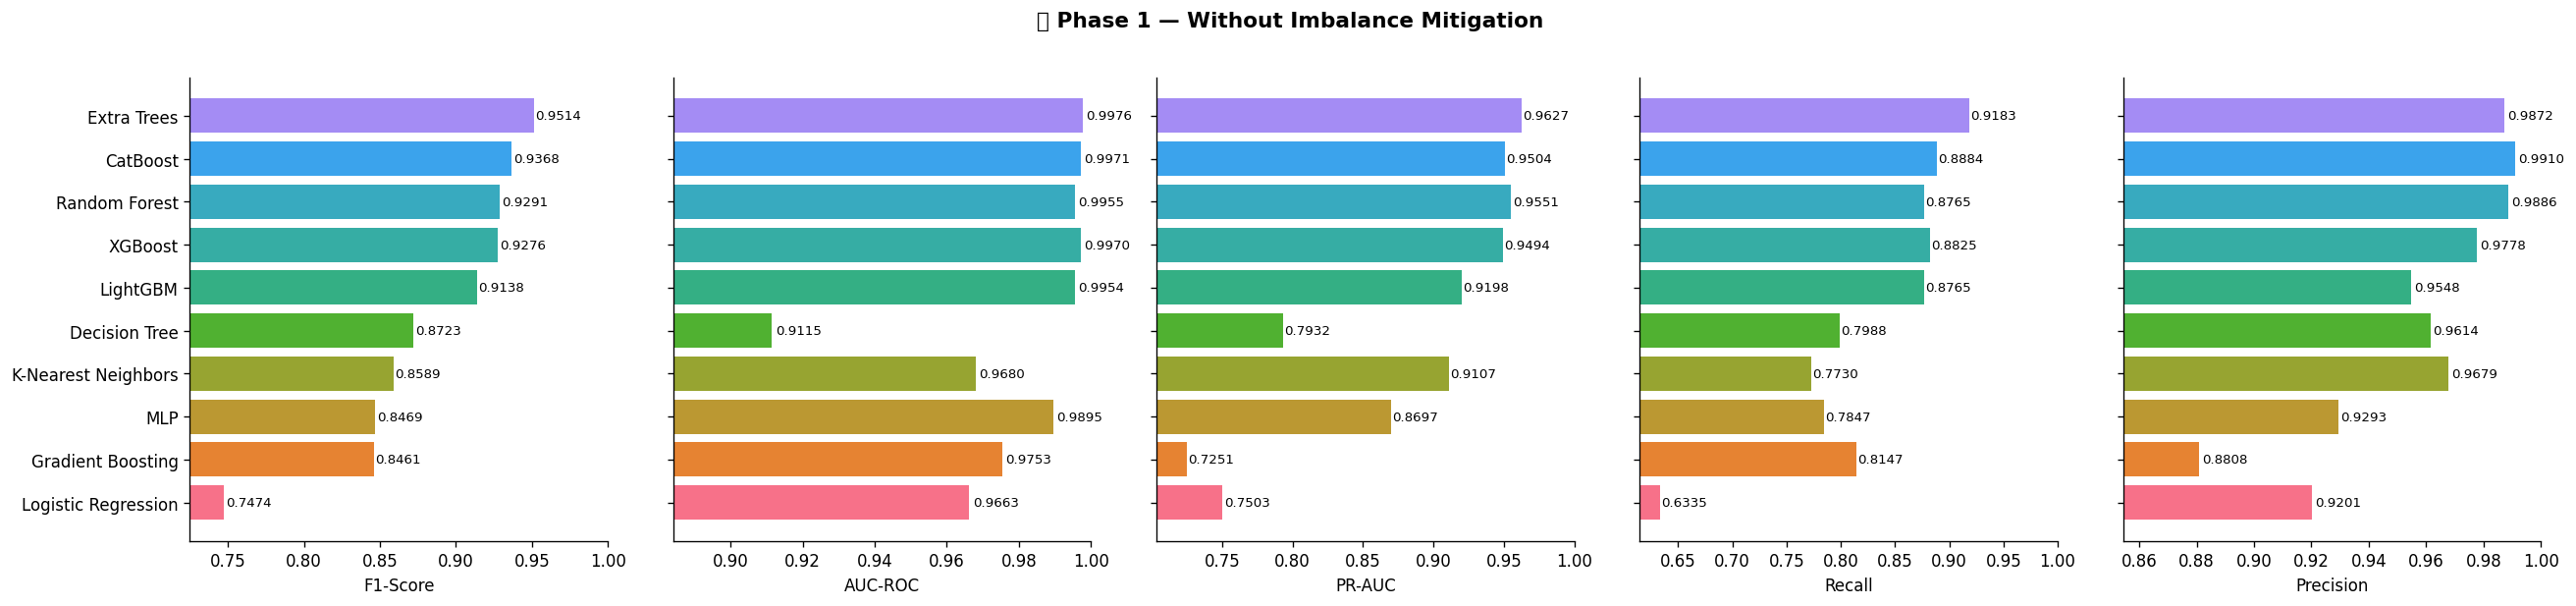

In [12]:
plot_leaderboard(p1_df, ' Phase 1 — Without Imbalance Mitigation')

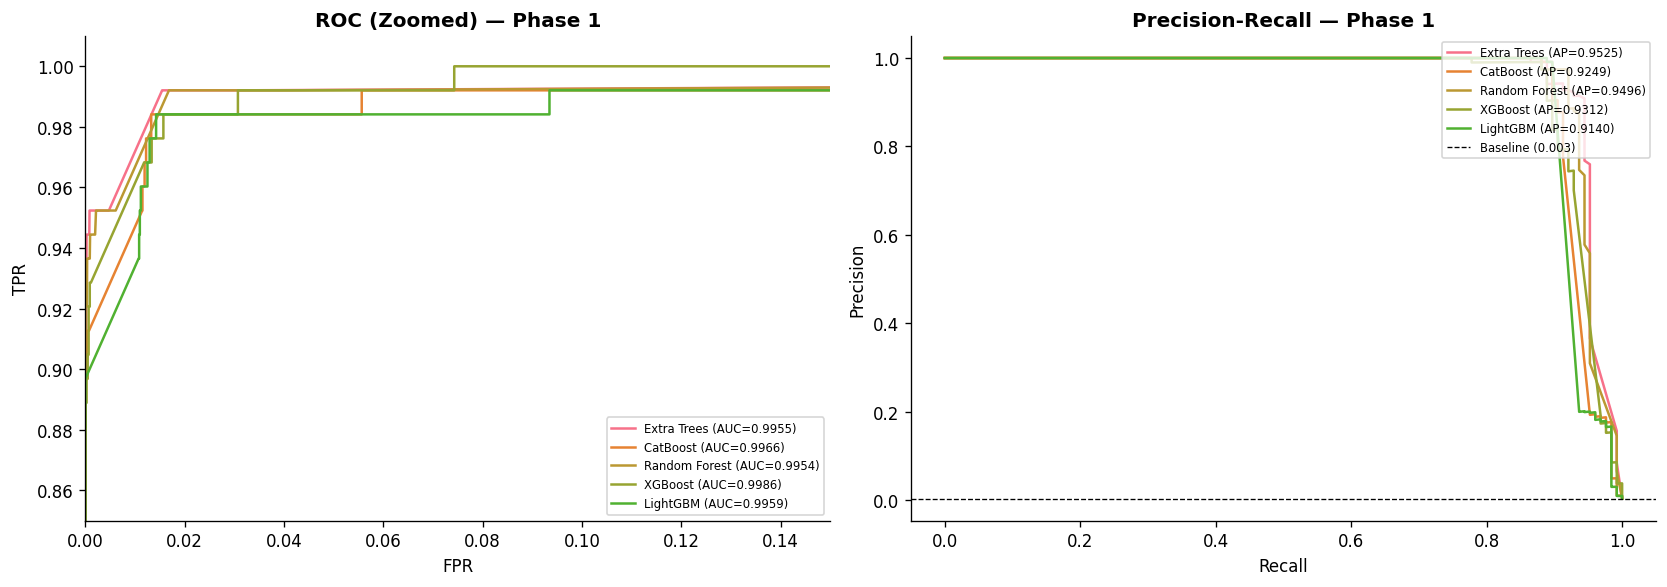

In [13]:
top5_p1 = p1_df['Model'].head(5).tolist()
plot_roc_pr(phase1_pipes, X_test, y_test, top5_p1, 'Phase 1')

### 5.3 Test-set Evaluation — Best Model (Phase 1)


── Test-set evaluation: Phase 1 Best — Extra Trees ──────────────────────────────
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998     43650
           1     0.9911    0.8810    0.9328       126

    accuracy                         0.9996     43776
   macro avg     0.9954    0.9405    0.9663     43776
weighted avg     0.9996    0.9996    0.9996     43776

MCC  : 0.9342
Bal. Accuracy: 0.9405
PR-AUC: 0.9525


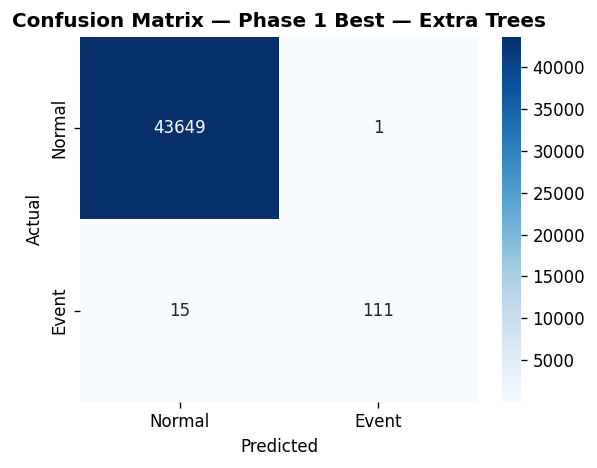

In [14]:
best_p1_name = p1_df.iloc[0]['Model']
best_p1_pipe = phase1_pipes[best_p1_name]
_ = evaluate_on_test(best_p1_pipe, X_test, y_test, f'Phase 1 Best — {best_p1_name}')

---
#  PHASE 2: Training WITH Data Imbalance Mitigation

Multiple strategies applied **inside** the cross-validation loop (no leakage):

| Strategy | Description |
|---|---|
| **class_weight** | Built-in cost-sensitive weighting (for applicable models) |
| **SMOTE** | Synthetic Minority Over-sampling Technique |
| **BorderlineSMOTE** | SMOTE focused on borderline minority samples |
| **SMOTE + Tomek** | Over-sampling + Tomek link cleaning |
| **SMOTE + ENN** | Over-sampling + Edited Nearest Neighbours cleaning |
| **scale_pos_weight** | XGBoost/LightGBM native imbalance handling |

### 6.1 Define Classifiers (Phase 2 — cost-sensitive)

In [22]:
phase2_classifiers = {
    'Logistic Regression':   LogisticRegression(max_iter=2000, C=1.0,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE),
    'Extra Trees':           ExtraTreesClassifier(n_estimators=300,
                                                   class_weight='balanced',
                                                   n_jobs=-1, random_state=RANDOM_STATE),
    'Random Forest':         RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                                     class_weight='balanced_subsample',
                                                     n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                         max_depth=5, subsample=0.8,
                                                         random_state=RANDOM_STATE),
    'XGBoost':               XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                            subsample=0.8, colsample_bytree=0.8,
                                            scale_pos_weight=spw,          # ← imbalance
                                            min_child_weight=3, gamma=0.1,
                                            eval_metric='logloss', n_jobs=-1,
                                            random_state=RANDOM_STATE),
    'CatBoost':              CatBoostClassifier(iterations=500, learning_rate=0.05, depth=7,
                                                 l2_leaf_reg=3, loss_function='Logloss',
                                                 auto_class_weights='Balanced',  # ← imbalance
                                                 thread_count=-1, verbose=0,
                                                 random_seed=RANDOM_STATE),
    'MLP':                   MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                                            learning_rate_init=1e-3, max_iter=1000,
                                            early_stopping=True, validation_fraction=0.1,
                                            random_state=RANDOM_STATE),
}

# Resampling strategies to try
resamplers = {
    'SMOTE':            SMOTE(random_state=RANDOM_STATE),
    'BorderlineSMOTE':  BorderlineSMOTE(random_state=RANDOM_STATE),
    'SMOTE+Tomek':      SMOTETomek(random_state=RANDOM_STATE),
    'SMOTE+ENN':        SMOTEENN(random_state=RANDOM_STATE),
}
print(f'Phase 2 — {len(phase2_classifiers)} classifiers × {len(resamplers)} resamplers')

Phase 2 — 7 classifiers × 4 resamplers


### 6.2 Cross-Validation — Best Resampler per Model

In [23]:
# For SOTA speed: compare resamplers only for top-3 candidates, use best for rest
# You can set FULL_SEARCH=True to test all combinations (slower)
FULL_SEARCH = False

phase2_results  = []
phase2_pipes    = {}

# Find best resampler using Random Forest as probe
print(' Finding best resampler (using Random Forest as probe)...')
rf_probe = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                    n_jobs=-1, random_state=RANDOM_STATE)
best_resampler_name, best_resampler_f1 = 'SMOTE', 0
for rs_name, resampler in resamplers.items():
    probe_pipe = ImbPipeline([
        ('scaler',    RobustScaler()),
        ('resampler', resampler),
        ('clf',       rf_probe)
    ])
    scores = cross_validate(probe_pipe, X_train_full, y_train_full,
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
    f1 = scores['test_score'].mean()
    print(f'  {rs_name:20s} → F1={f1:.4f}')
    if f1 > best_resampler_f1:
        best_resampler_f1  = f1
        best_resampler_name = rs_name

print(f'\n Best resampler: {best_resampler_name} (F1={best_resampler_f1:.4f})')
best_resampler = resamplers[best_resampler_name]

 Finding best resampler (using Random Forest as probe)...
  SMOTE                → F1=0.3563
  BorderlineSMOTE      → F1=0.9182
  SMOTE+Tomek          → F1=0.3563
  SMOTE+ENN            → F1=0.9080

 Best resampler: BorderlineSMOTE (F1=0.9182)


In [24]:
print('\n Phase 2 — CV with imbalance mitigation\n')

for name, clf in phase2_classifiers.items():
    print(f'    {name} ...', end=' ', flush=True)
    pipe = ImbPipeline([
        ('scaler',    RobustScaler()),
        ('resampler', best_resampler),
        ('clf',       clf)
    ])
    result = run_cv(name, pipe, X_train_full, y_train_full, cv)
    phase2_results.append(result)
    pipe.fit(X_train_full, y_train_full)
    phase2_pipes[name] = pipe
    print(f"F1={result['F1-Score']:.4f}  AUC={result['AUC-ROC']:.4f}")

p2_df = (pd.DataFrame(phase2_results)
           .sort_values('F1-Score', ascending=False)
           .reset_index(drop=True))
print('\n Phase 2 CV complete')


 Phase 2 — CV with imbalance mitigation

    Logistic Regression ... F1=0.4373  AUC=0.9581
    Extra Trees ... F1=0.9350  AUC=0.9994
    Random Forest ... F1=0.9253  AUC=0.9980
    Gradient Boosting ... F1=0.8931  AUC=0.9929
    XGBoost ... F1=0.3645  AUC=0.9963
    CatBoost ... F1=0.9120  AUC=0.9959
    MLP ... F1=0.8761  AUC=0.9871

 Phase 2 CV complete


In [25]:
p2_df[display_cols].style.background_gradient(subset=['F1-Score','AUC-ROC','PR-AUC'], cmap='YlOrRd')

,Model,F1-Score,AUC-ROC,PR-AUC,Precision,Recall,Accuracy,F1 Std,Time (s)
0,Extra Trees,0.935033,0.999381,0.959237,0.952423,0.918317,0.999635,0.014423,194.400000
1,Random Forest,0.925285,0.997983,0.948404,0.951665,0.900356,0.999583,0.017590,379.600000
2,CatBoost,0.911951,0.995917,0.943386,0.896348,0.928257,0.999486,0.015869,87.400000
3,Gradient Boosting,0.893085,0.992933,0.867124,0.864075,0.924257,0.999366,0.010156,2261.300000
4,MLP,0.876132,0.987120,0.883447,0.855839,0.898376,0.999269,0.026558,76.200000
5,Logistic Regression,0.437306,0.958105,0.683119,0.292938,0.866495,0.993558,0.034725,230.100000
6,XGBoost,0.364488,0.996276,0.945854,0.224222,0.976079,0.990212,0.016262,42.700000


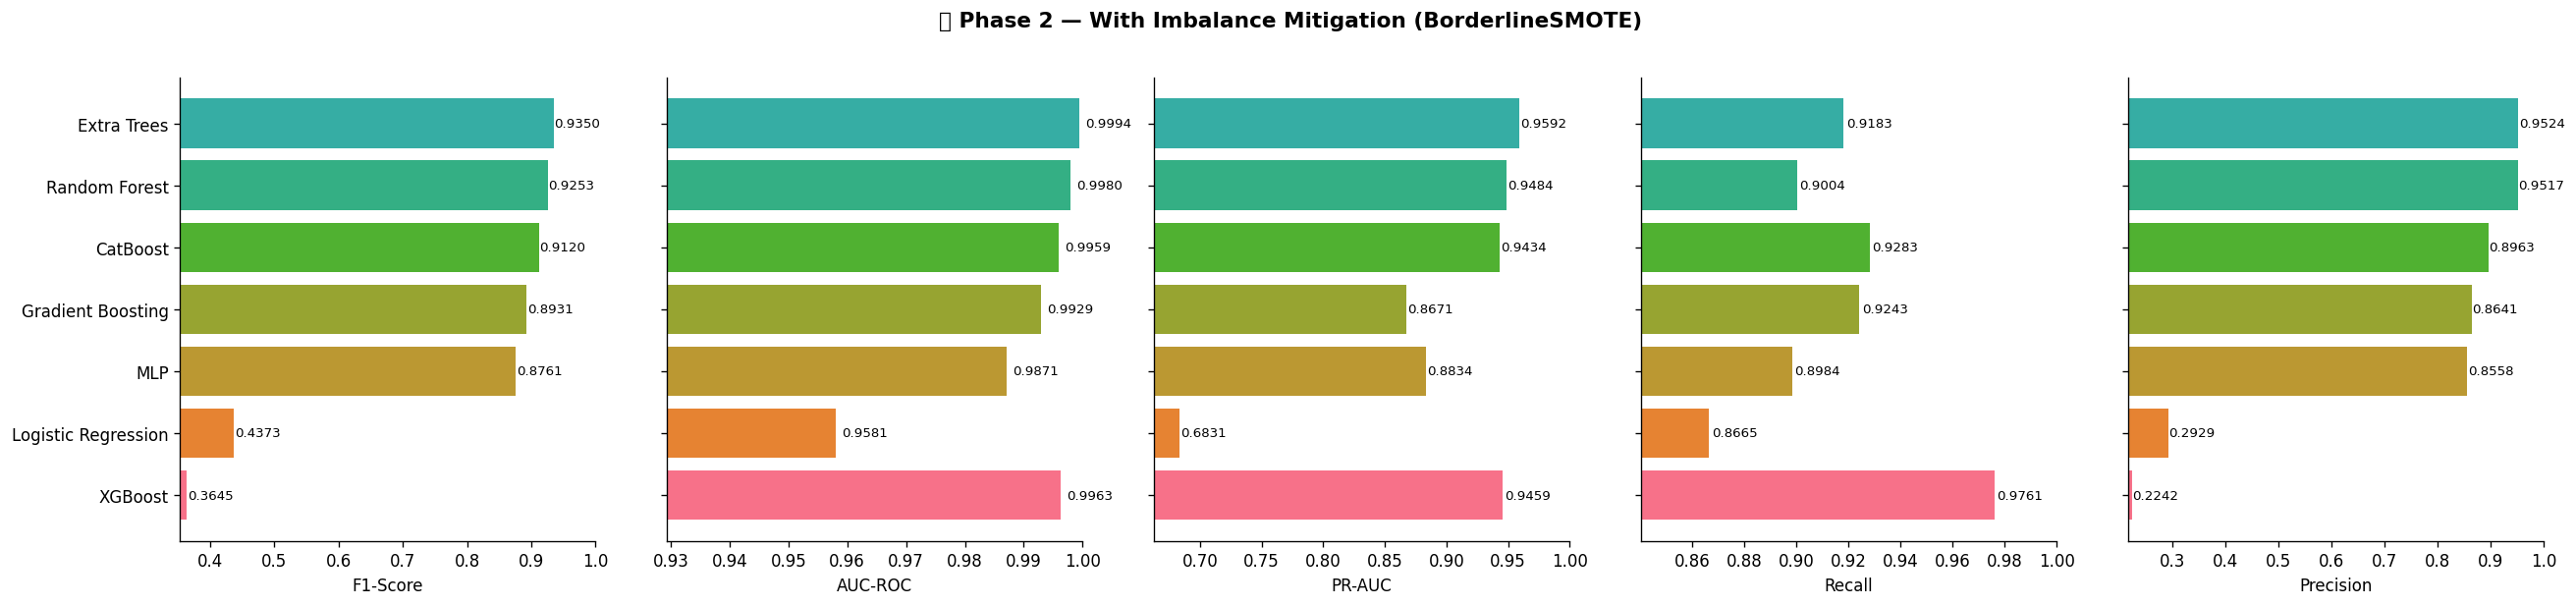

In [26]:
plot_leaderboard(p2_df, f' Phase 2 — With Imbalance Mitigation ({best_resampler_name})')

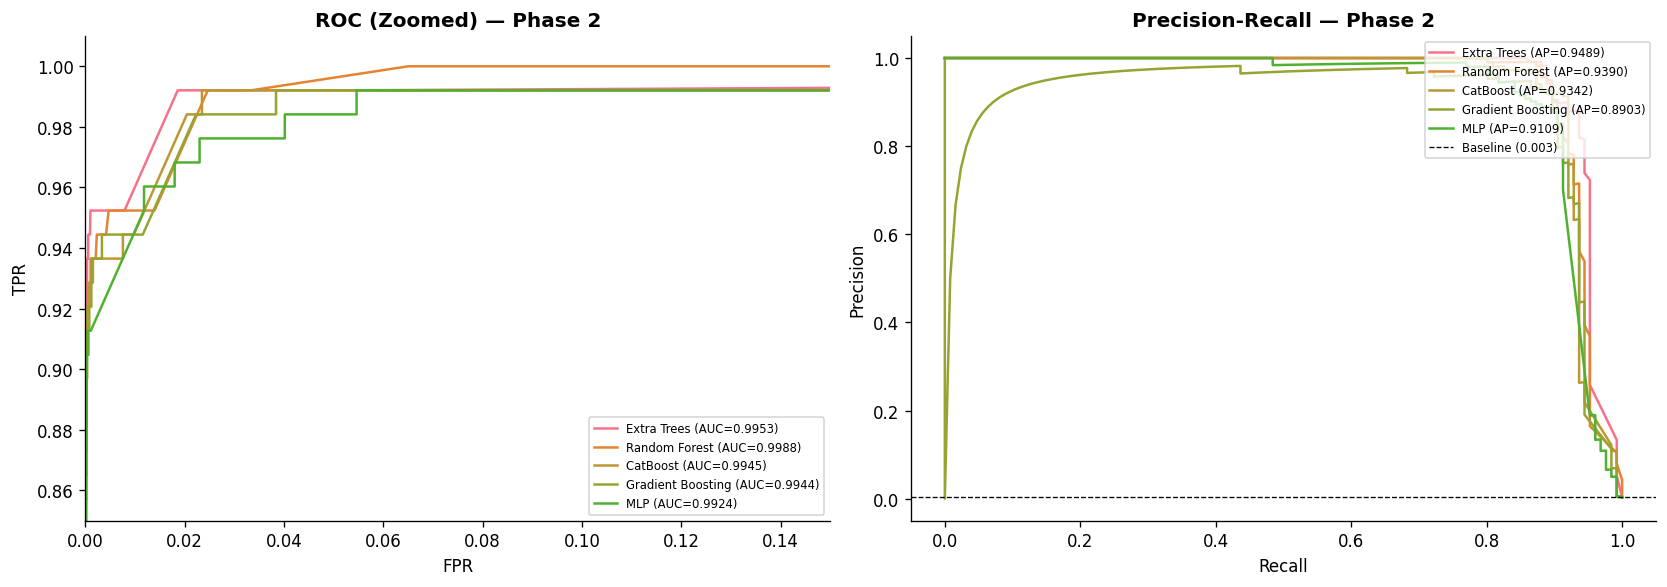

In [27]:
top5_p2 = p2_df['Model'].head(5).tolist()
plot_roc_pr(phase2_pipes, X_test, y_test, top5_p2, 'Phase 2')

### 6.3 Test-set Evaluation — Best Model (Phase 2)


── Test-set evaluation: Phase 2 Best — Extra Trees ──────────────────────────────
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     43650
           1     0.9655    0.8889    0.9256       126

    accuracy                         0.9996     43776
   macro avg     0.9826    0.9444    0.9627     43776
weighted avg     0.9996    0.9996    0.9996     43776

MCC  : 0.9262
Bal. Accuracy: 0.9444
PR-AUC: 0.9489


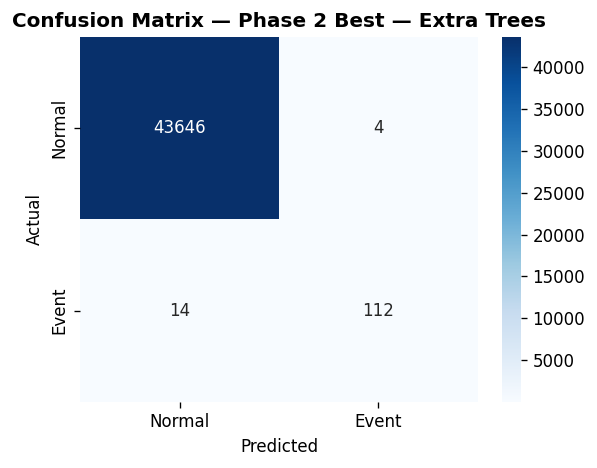

In [28]:
best_p2_name = p2_df.iloc[0]['Model']
best_p2_pipe = phase2_pipes[best_p2_name]
_ = evaluate_on_test(best_p2_pipe, X_test, y_test, f'Phase 2 Best — {best_p2_name}')

---
#  PHASE 2+: Optuna Hyperparameter Optimization

Optuna TPE search on the top-3 Phase 2 models for SOTA performance.

In [29]:
N_TRIALS = 50  # increase to 100+ for better tuning

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'scale_pos_weight':  spw,
        'eval_metric': 'logloss', 'n_jobs': -1, 'random_state': RANDOM_STATE
    }
    pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('resampler', best_resampler),
        ('clf', XGBClassifier(**params))
    ])
    scores = cross_validate(pipe, X_train_full, y_train_full,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
    return scores['test_score'].mean()

def objective_lgbm(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'is_unbalance': True, 'n_jobs': -1,
        'random_state': RANDOM_STATE, 'verbose': -1
    }
    pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('resampler', best_resampler),
        ('clf', LGBMClassifier(**params))
    ])
    scores = cross_validate(pipe, X_train_full, y_train_full,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
    return scores['test_score'].mean()

def objective_catboost(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength':     trial.suggest_float('random_strength', 0, 10),
        'loss_function': 'Logloss', 'auto_class_weights': 'Balanced',
        'thread_count': -1, 'verbose': 0, 'random_seed': RANDOM_STATE
    }
    pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('resampler', best_resampler),
        ('clf', CatBoostClassifier(**params))
    ])
    scores = cross_validate(pipe, X_train_full, y_train_full,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
    return scores['test_score'].mean()

objectives = {
    'XGBoost (Tuned)':   (objective_xgb,      XGBClassifier),
    'LightGBM (Tuned)':  (objective_lgbm,     LGBMClassifier),
    'CatBoost (Tuned)':  (objective_catboost, CatBoostClassifier),
}
print(f'🔧 Will run {N_TRIALS} Optuna trials × {len(objectives)} models')

🔧 Will run 50 Optuna trials × 3 models


In [30]:
optuna_results  = []
optuna_pipes    = {}
best_params_all = {}

for name, (obj_fn, _) in objectives.items():
    print(f'\n Optimizing {name} ({N_TRIALS} trials)...')
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)
    best_params_all[name] = study.best_params
    print(f'  Best CV F1: {study.best_value:.4f}')
    print(f'  Best params: {study.best_params}')

print('\n Optuna optimization complete')


 Optimizing XGBoost (Tuned) (50 trials)...


Best trial: 41. Best value: 0.367078: 100%|██████████| 50/50 [27:36<00:00, 33.12s/it]


  Best CV F1: 0.3671
  Best params: {'n_estimators': 485, 'learning_rate': 0.15987016877139978, 'max_depth': 3, 'subsample': 0.6098452383037042, 'colsample_bytree': 0.5315922566999599, 'min_child_weight': 4, 'gamma': 0.16819755363979144, 'reg_alpha': 2.8676211855137165e-06, 'reg_lambda': 0.12945336156083645}

 Optimizing LightGBM (Tuned) (50 trials)...


Best trial: 6. Best value: 0.948159: 100%|██████████| 50/50 [27:21<00:00, 32.83s/it]


  Best CV F1: 0.9482
  Best params: {'n_estimators': 559, 'learning_rate': 0.15826541904647565, 'num_leaves': 31, 'max_depth': 4, 'min_child_samples': 7, 'subsample': 0.6626651653816322, 'colsample_bytree': 0.6943386448447411, 'reg_alpha': 2.7678419414850017e-06, 'reg_lambda': 0.28749982347407854}

 Optimizing CatBoost (Tuned) (50 trials)...


Best trial: 25. Best value: 0.921985: 100%|██████████| 50/50 [1:45:45<00:00, 126.91s/it]

  Best CV F1: 0.9220
  Best params: {'iterations': 761, 'learning_rate': 0.022296987115535145, 'depth': 6, 'l2_leaf_reg': 1.0347600497370912, 'bagging_temperature': 0.8266781626654027, 'random_strength': 2.400784928737373}

 Optuna optimization complete


In [31]:
# Re-build best models and evaluate on full 10-fold CV
for name, best_p in best_params_all.items():
    print(f'   Fitting {name} with best params...')
    if 'XGBoost' in name:
        clf = XGBClassifier(**best_p, eval_metric='logloss',
                             n_jobs=-1, random_state=RANDOM_STATE)
    elif 'LightGBM' in name:
        clf = LGBMClassifier(**best_p, n_jobs=-1,
                              random_state=RANDOM_STATE, verbose=-1)
    else:
        clf = CatBoostClassifier(**best_p, thread_count=-1,
                                  verbose=0, random_seed=RANDOM_STATE)
    pipe = ImbPipeline([
        ('scaler',    RobustScaler()),
        ('resampler', best_resampler),
        ('clf',       clf)
    ])
    result = run_cv(name, pipe, X_train_full, y_train_full, cv)
    optuna_results.append(result)
    pipe.fit(X_train_full, y_train_full)
    optuna_pipes[name] = pipe
    print(f"    F1={result['F1-Score']:.4f}  AUC={result['AUC-ROC']:.4f}  PR-AUC={result['PR-AUC']:.4f}")

optuna_df = (pd.DataFrame(optuna_results)
               .sort_values('F1-Score', ascending=False)
               .reset_index(drop=True))
print('\n Tuned models evaluated')

   Fitting XGBoost (Tuned) with best params...
    F1=0.9309  AUC=0.9961  PR-AUC=0.9563
   Fitting LightGBM (Tuned) with best params...
    F1=0.9482  AUC=0.9968  PR-AUC=0.9564
   Fitting CatBoost (Tuned) with best params...
    F1=0.9220  AUC=0.9962  PR-AUC=0.9451

 Tuned models evaluated


---
#  SOTA Ensemble — Soft Voting Stack

Combine the best models from Phase 2 + Optuna-tuned models into a soft-voting ensemble.

In [32]:
# Select top-3 from Phase 2 + all Optuna-tuned models
top3_p2 = p2_df['Model'].head(3).tolist()

ensemble_estimators = []
for name in top3_p2:
    ensemble_estimators.append((f'p2_{name.replace(" ","_")}', phase2_pipes[name]))
for name in optuna_pipes:
    ensemble_estimators.append((f'opt_{name.replace(" ","_")}', optuna_pipes[name]))

print('Ensemble members:')
for n, _ in ensemble_estimators:
    print(f'  • {n}')

# Soft voting ensemble
voting_ens = VotingClassifier(estimators=ensemble_estimators, voting='soft', n_jobs=-1)
print(f'\nTotal ensemble members: {len(ensemble_estimators)}')

Ensemble members:
  • p2_Extra_Trees
  • p2_Random_Forest
  • p2_CatBoost
  • opt_XGBoost_(Tuned)
  • opt_LightGBM_(Tuned)
  • opt_CatBoost_(Tuned)

Total ensemble members: 6


In [33]:
print(' Evaluating Soft Voting Ensemble (10-fold CV)...')
ens_result = run_cv('Soft Voting Ensemble', voting_ens,
                     X_train_full, y_train_full, cv)
print(f"  F1={ens_result['F1-Score']:.4f}  AUC={ens_result['AUC-ROC']:.4f}  PR-AUC={ens_result['PR-AUC']:.4f}")

voting_ens.fit(X_train_full, y_train_full)
print(' Ensemble fitted')

 Evaluating Soft Voting Ensemble (10-fold CV)...
  F1=0.9370  AUC=0.9991  PR-AUC=0.9568
 Ensemble fitted


## 8. Final Comparison — All Phases

In [34]:
# Tag each result with its phase
p1_df_tag  = p1_df.assign(Phase='Phase 1 (No Mitigation)')
p2_df_tag  = p2_df.assign(Phase=f'Phase 2 ({best_resampler_name})')
opt_df_tag = optuna_df.assign(Phase='Phase 2+ (Optuna Tuned)')
ens_df_tag = pd.DataFrame([ens_result]).assign(Phase=' Ensemble')

all_df = pd.concat([p1_df_tag, p2_df_tag, opt_df_tag, ens_df_tag], ignore_index=True)
all_df = all_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

# Summary table
summary_cols = ['Phase','Model','F1-Score','AUC-ROC','PR-AUC','Recall','Precision','Accuracy']
all_df[summary_cols].head(15).style.background_gradient(
    subset=['F1-Score','AUC-ROC','PR-AUC'], cmap='RdYlGn'
)

,Phase,Model,F1-Score,AUC-ROC,PR-AUC,Recall,Precision,Accuracy
0,Phase 1 (No Mitigation),Extra Trees,0.951430,0.997580,0.962662,0.918337,0.987184,0.999732
1,Phase 2+ (Optuna Tuned),LightGBM (Tuned),0.948159,0.996792,0.956355,0.928317,0.968942,0.999709
2,Ensemble,Soft Voting Ensemble,0.936953,0.999129,0.956793,0.932277,0.941848,0.999640
3,Phase 1 (No Mitigation),CatBoost,0.936776,0.997081,0.950362,0.888396,0.991031,0.999657
4,Phase 2 (BorderlineSMOTE),Extra Trees,0.935033,0.999381,0.959237,0.918317,0.952423,0.999635
5,Phase 2+ (Optuna Tuned),XGBoost (Tuned),0.930901,0.996138,0.956288,0.926337,0.935781,0.999606
6,Phase 1 (No Mitigation),Random Forest,0.929076,0.995454,0.955147,0.876495,0.988627,0.999617
7,Phase 1 (No Mitigation),XGBoost,0.927618,0.997035,0.949378,0.882455,0.977792,0.999606
8,Phase 2 (BorderlineSMOTE),Random Forest,0.925285,0.997983,0.948404,0.900356,0.951665,0.999583
9,Phase 2+ (Optuna Tuned),CatBoost (Tuned),0.921985,0.996206,0.945076,0.928257,0.916269,0.999549


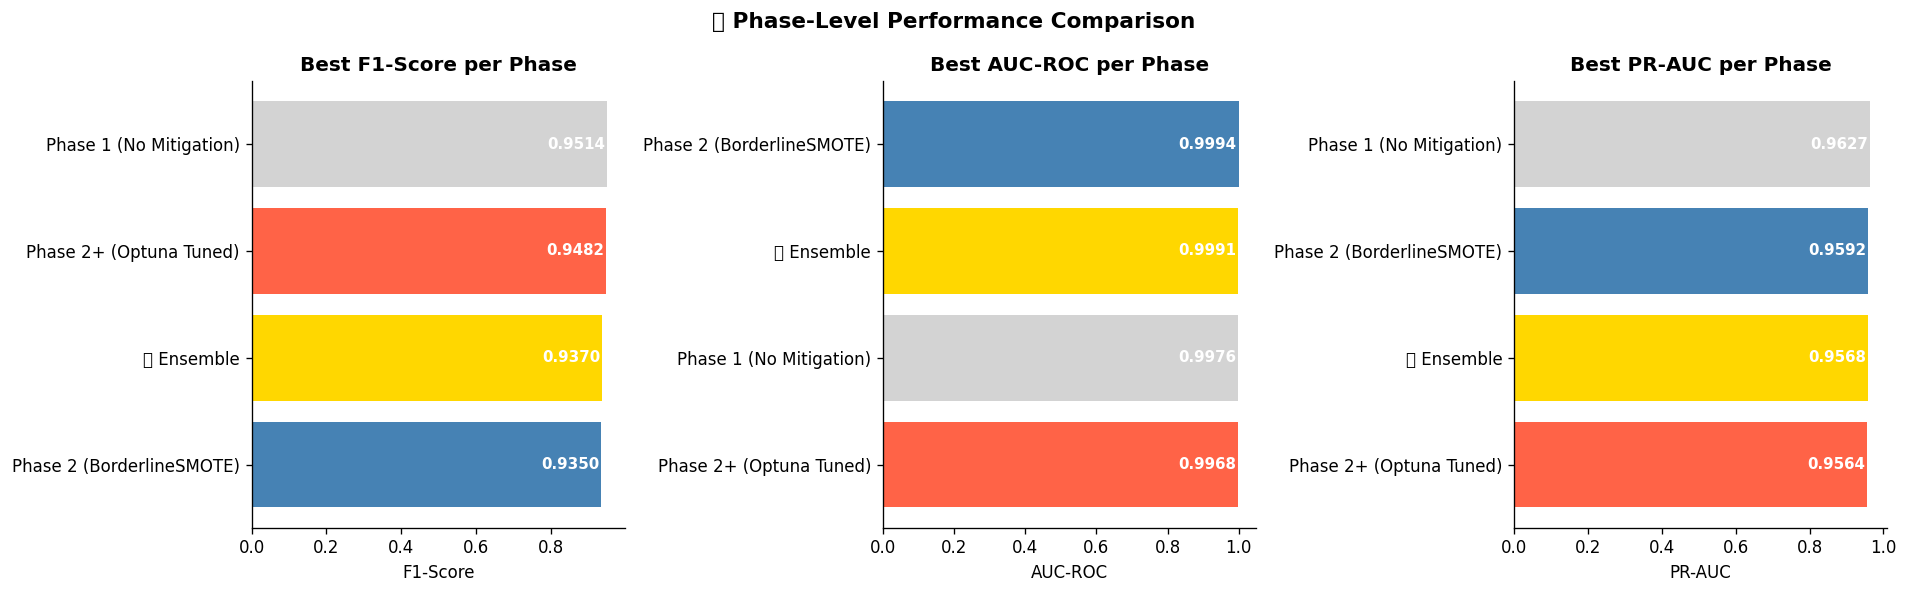

In [35]:
# Phase-level comparison (box chart)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['F1-Score', 'AUC-ROC', 'PR-AUC']):
    phase_means = all_df.groupby('Phase')[metric].max().sort_values(ascending=False)
    colors = ['gold' if '' in p else
               'tomato' if 'Optuna' in p else
               'steelblue' if 'Phase 2' in p else 'lightgray'
               for p in phase_means.index]
    bars = ax.barh(phase_means.index[::-1], phase_means.values[::-1], color=colors[::-1])
    ax.set_xlabel(metric)
    ax.set_title(f'Best {metric} per Phase', fontweight='bold')
    for bar in bars:
        w = bar.get_width()
        ax.text(w - 0.005, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)

plt.suptitle(' Phase-Level Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Final Test-set Evaluation — SOTA Ensemble


── Test-set evaluation:  SOTA Soft Voting Ensemble ──────────────────────────────
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     43650
           1     0.9739    0.8889    0.9295       126

    accuracy                         0.9996     43776
   macro avg     0.9868    0.9444    0.9646     43776
weighted avg     0.9996    0.9996    0.9996     43776

MCC  : 0.9302
Bal. Accuracy: 0.9444
PR-AUC: 0.9467


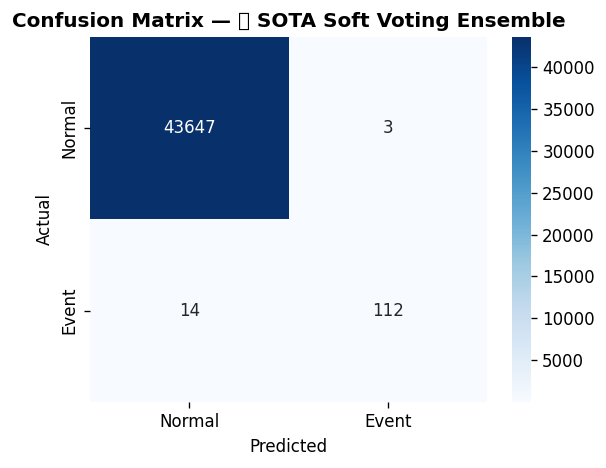

In [36]:
ens_proba = evaluate_on_test(voting_ens, X_test, y_test, ' SOTA Soft Voting Ensemble')

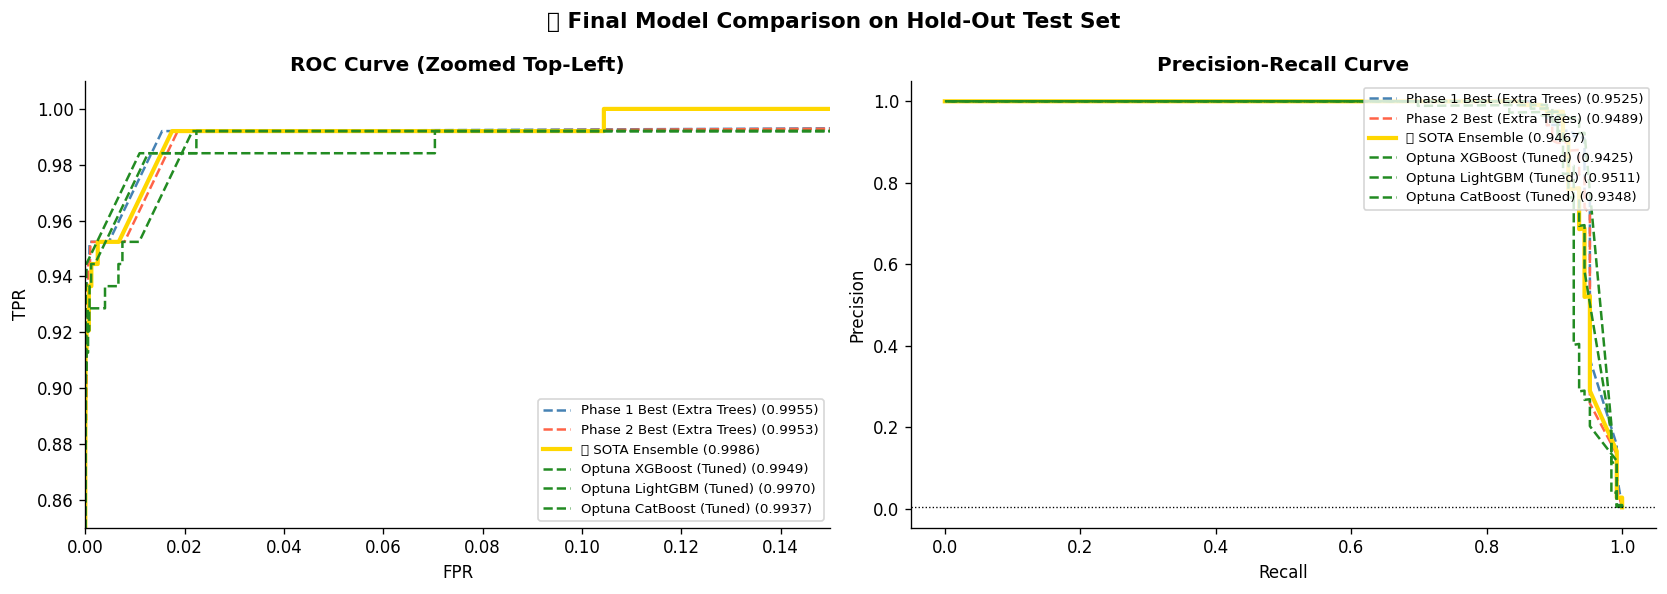

In [37]:
# ROC + PR curve for ensemble vs best Phase 1 & 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

compare_models = {
    f'Phase 1 Best ({best_p1_name})': (phase1_pipes[best_p1_name], 'steelblue'),
    f'Phase 2 Best ({best_p2_name})': (phase2_pipes[best_p2_name], 'tomato'),
    ' SOTA Ensemble':               (voting_ens, 'gold'),
}
for opt_n, opt_p in optuna_pipes.items():
    compare_models[f'Optuna {opt_n}'] = (opt_p, 'forestgreen')

for label, (pipe, color) in compare_models.items():
    yp = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax1.plot(fpr, tpr, label=f'{label} ({auc(fpr,tpr):.4f})', color=color,
              lw=2.5 if '' in label else 1.5,
              ls='-' if '' in label else '--')
    pr, rc, _ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    ax2.plot(rc, pr, label=f'{label} ({ap:.4f})', color=color,
              lw=2.5 if '' in label else 1.5,
              ls='-' if '' in label else '--')

ax1.plot([0,1],[0,1],'k--', lw=0.8); ax1.set_xlim([0,0.15]); ax1.set_ylim([0.85,1.01])
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve (Zoomed Top-Left)', fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')

ax2.axhline(y_test.mean(), color='k', ls=':', lw=0.8)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')

plt.suptitle(' Final Model Comparison on Hold-Out Test Set', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. SHAP Explainability

We explain the best tree model using SHAP values.

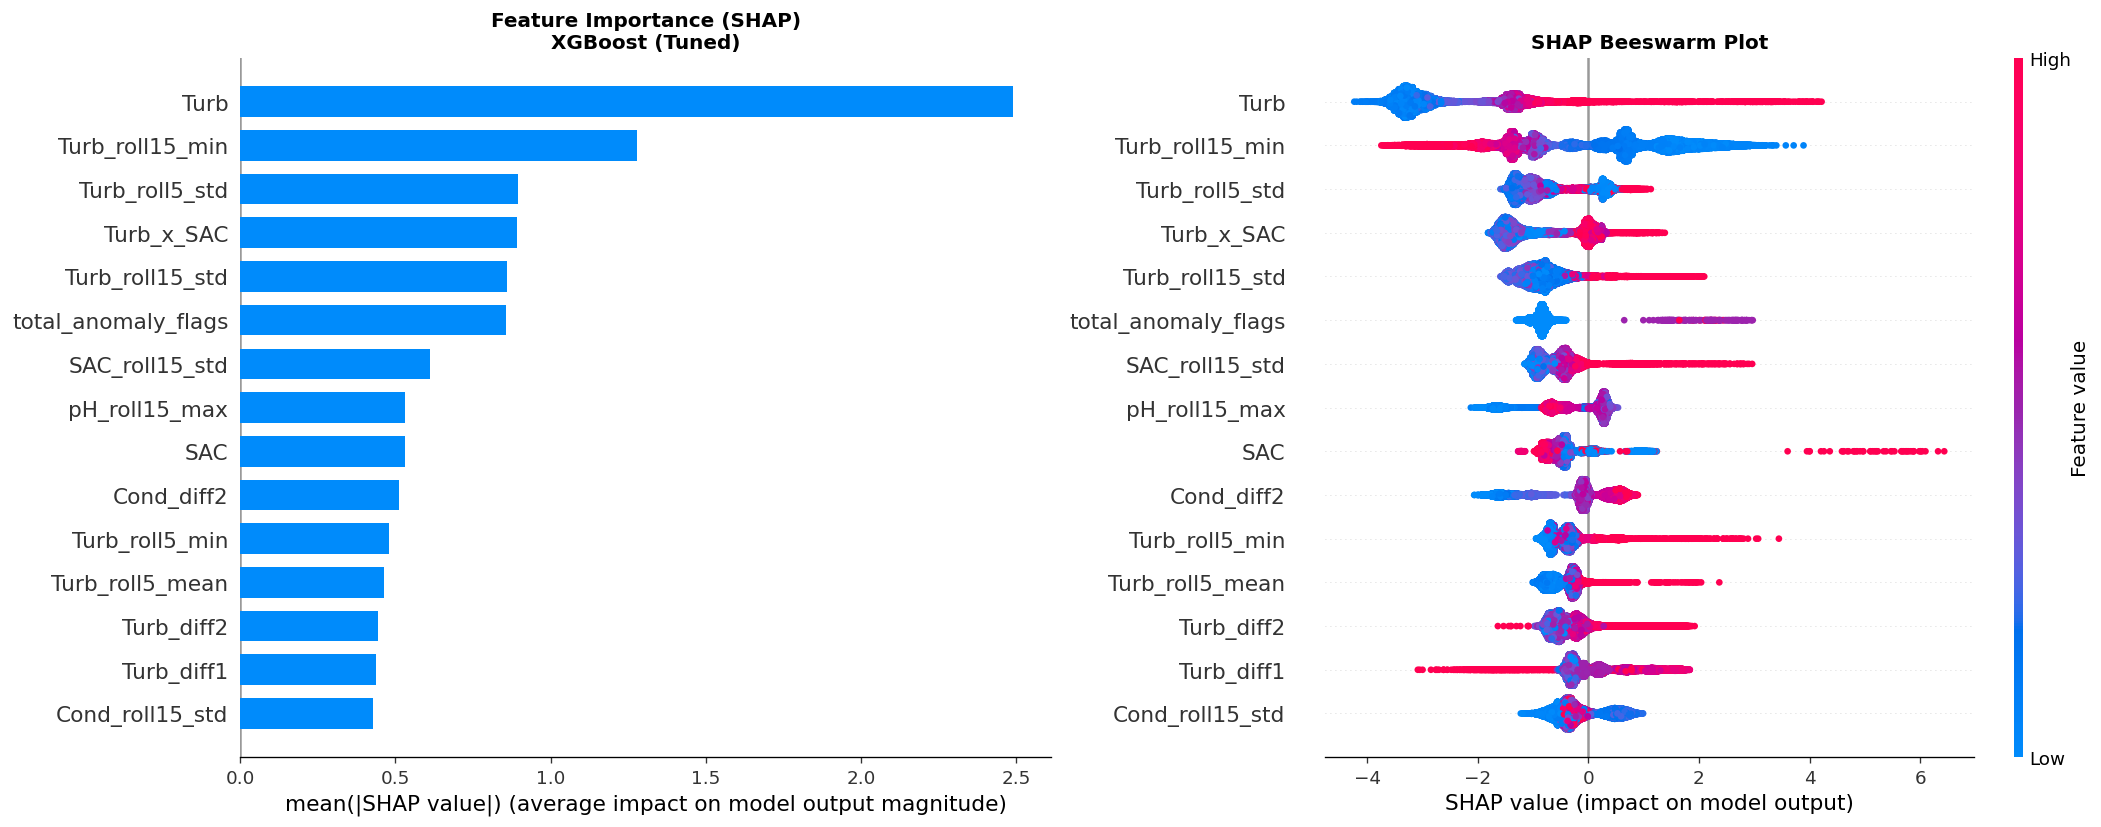

In [38]:
if SHAP_AVAILABLE:
    # Use best optuna model for SHAP (must be a tree model)
    shap_model_name = list(optuna_pipes.keys())[0]
    shap_pipe = optuna_pipes[shap_model_name]

    # Extract the fitted classifier and the scaled X_test
    scaler_step = shap_pipe.named_steps['scaler']
    clf_step    = shap_pipe.named_steps['clf']
    X_test_scaled = pd.DataFrame(scaler_step.transform(X_test), columns=X_test.columns)

    # TreeExplainer
    explainer = shap.TreeExplainer(clf_step)
    shap_values = explainer.shap_values(X_test_scaled)

    # Handle multi-class output
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(ax1)
    shap.summary_plot(sv, X_test_scaled, plot_type='bar', max_display=15,
                      show=False, plot_size=None)
    ax1.set_title(f'Feature Importance (SHAP)\n{shap_model_name}', fontweight='bold')

    plt.sca(ax2)
    shap.summary_plot(sv, X_test_scaled, max_display=15, show=False, plot_size=None)
    ax2.set_title('SHAP Beeswarm Plot', fontweight='bold')

    plt.tight_layout(); plt.show()
else:
    print('SHAP not available. Install with: pip install shap')

## 11. Summary Report

In [ ]:
print('=' * 65)
print(' GECCO 2019 Water Quality — SOTA Pipeline Summary')
print('=' * 65)

print(f'\nFeatures engineered : {X_train_full.shape[1]}')
print(f'Training samples    : {X_train_full.shape[0]:,}')
print(f'Test samples        : {X_test.shape[0]:,}')
print(f'Class imbalance     : {spw:.1f}:1  (neg:pos)')
print(f'CV strategy         : StratifiedKFold (k=10)')

print('\n── Phase 1 Best (No Mitigation) ──')
r1 = p1_df.iloc[0]
print(f"  Model    : {r1['Model']}")
print(f"  CV F1    : {r1['F1-Score']:.4f} ± {r1['F1 Std']:.4f}")
print(f"  CV AUC   : {r1['AUC-ROC']:.4f}")
print(f"  CV PR-AUC: {r1['PR-AUC']:.4f}")

print(f'\n── Phase 2 Best ({best_resampler_name}) ──')
r2 = p2_df.iloc[0]
print(f"  Model    : {r2['Model']}")
print(f"  CV F1    : {r2['F1-Score']:.4f} ± {r2['F1 Std']:.4f}")
print(f"  CV AUC   : {r2['AUC-ROC']:.4f}")
print(f"  CV PR-AUC: {r2['PR-AUC']:.4f}")

print('\n── Phase 2+ Optuna Tuned ──')
for _, row in optuna_df.iterrows():
    print(f"  {row['Model']:25s} F1={row['F1-Score']:.4f}  AUC={row['AUC-ROC']:.4f}  PR-AUC={row['PR-AUC']:.4f}")

print('\n──  SOTA Ensemble ──')
print(f"  CV F1    : {ens_result['F1-Score']:.4f} ± {ens_result['F1 Std']:.4f}")
print(f"  CV AUC   : {ens_result['AUC-ROC']:.4f}")
print(f"  CV PR-AUC: {ens_result['PR-AUC']:.4f}")

# Test-set final
ens_y_pred  = voting_ens.predict(X_test)
ens_y_proba = voting_ens.predict_proba(X_test)[:, 1]
print('\n── Test-Set Final ──')
print(f"  F1       : {f1_score(y_test, ens_y_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, ens_y_proba):.4f}")
print(f"  PR-AUC   : {average_precision_score(y_test, ens_y_proba):.4f}")
print(f"  MCC      : {matthews_corrcoef(y_test, ens_y_pred):.4f}")
print(f"  Bal.Acc  : {balanced_accuracy_score(y_test, ens_y_pred):.4f}")
print('=' * 65)

 GECCO 2019 Water Quality — SOTA Pipeline Summary

Features engineered : 76
Training samples    : 175,104
Test samples        : 43,776
Class imbalance     : 347.8:1  (neg:pos)
CV strategy         : StratifiedKFold (k=10)

── Phase 1 Best (No Mitigation) ──
  Model    : Extra Trees
  CV F1    : 0.9514 ± 0.0139
  CV AUC   : 0.9976
  CV PR-AUC: 0.9627

── Phase 2 Best (BorderlineSMOTE) ──
  Model    : Extra Trees
  CV F1    : 0.9350 ± 0.0144
  CV AUC   : 0.9994
  CV PR-AUC: 0.9592

── Phase 2+ Optuna Tuned ──
  LightGBM (Tuned)          F1=0.9482  AUC=0.9968  PR-AUC=0.9564
  XGBoost (Tuned)           F1=0.9309  AUC=0.9961  PR-AUC=0.9563
  CatBoost (Tuned)          F1=0.9220  AUC=0.9962  PR-AUC=0.9451

──  SOTA Ensemble ──
  CV F1    : 0.9370 ± 0.0120
  CV AUC   : 0.9991
  CV PR-AUC: 0.9568

── Test-Set Final ──
  F1       : 0.9295
  AUC-ROC  : 0.9986
  PR-AUC   : 0.9467
  MCC      : 0.9302
  Bal.Acc  : 0.9444
